In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import cftime
import nc_time_axis
import sys
import calendar
import re
sys.path.append('C:/Users/madel/Code/GeoNorth/Observational_data')

from obs_utils import *

## Variable and Site settings

In [2]:
# Input the site ID and goal time length here

site = "BC"         # BC, TVC, HC, IQ, SC

ctsm_start = cftime.DatetimeNoLeap(1995, 1, 1, has_year_zero=True)
ctsm_end   = cftime.DatetimeNoLeap(2014, 12, 31, has_year_zero=True)

# SOIL TEMP

In [3]:
vari = "TSOI"  #SNOW_DEPTH, H2OSOI, TSOI
directory_path = f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/raw/{vari}"
times, values, depths = pull_files_dupe(directory_path)

In [4]:
print(depths)

[0.1, 0.2, 0.3, 0.46]


check that time shapes

In [5]:
check_shapes(times)

All arrays match: (3539,)


standardize all the time lengths

In [6]:
all_times = []
all_values = []

for x in range(0,len(times)):
    new_time, new_values = extend_time_and_values(
        times[x], values[x], ctsm_start, ctsm_end, freq="30T"
    )
    all_times.append(new_time)
    all_values.append(new_values)


check shapes and depths

In [7]:
check_shapes(all_times)
check_shapes(all_values)
print(depths)

All arrays match: (350353,)
All arrays match: (350353,)
[0.1, 0.2, 0.3, 0.46]


In [8]:
for i, (v, d) in enumerate(zip(all_values, depths)):
    print(f"[{i}] depth={d} non-nan={np.sum(~np.isnan(v))}")

[0] depth=0.1 non-nan=1091
[1] depth=0.2 non-nan=1714
[2] depth=0.3 non-nan=1738
[3] depth=0.46 non-nan=1551


In [9]:
data_2d = np.column_stack(all_values)

print(data_2d.shape)

(350353, 4)


In [10]:
ds_obs = make_obs_ds(vari, data_2d, all_times[0], site, "°C", depths)
ds_obs

<xarray.Dataset> Size: 14MB
Dimensions:  (time: 350353, depth: 4)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 32B 0.1 0.2 0.3 0.46
Data variables:
    TSOI     (time, depth) float64 11MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     BC
    source:   GWF observed

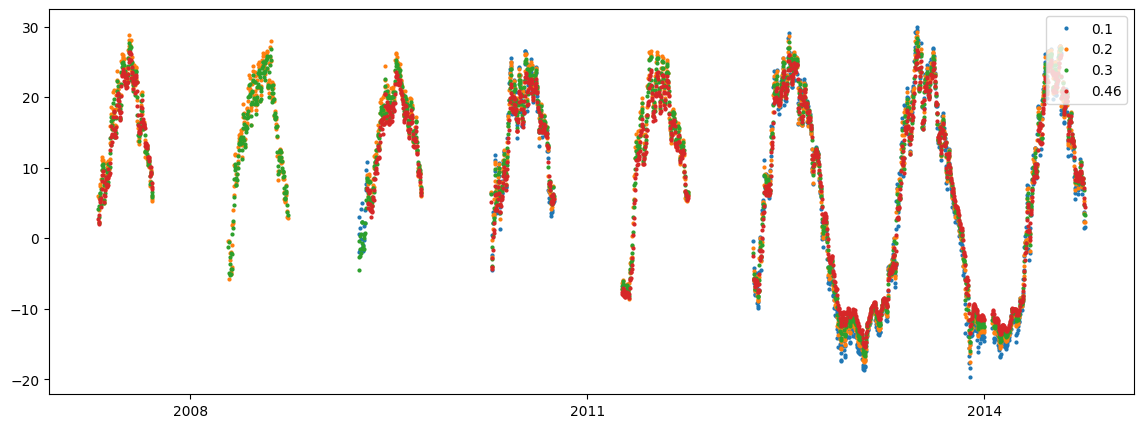

In [11]:
plot_disconnected(ds_obs, vari)

In [12]:
ds_obs

<xarray.Dataset> Size: 14MB
Dimensions:  (time: 350353, depth: 4)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 32B 0.1 0.2 0.3 0.46
Data variables:
    TSOI     (time, depth) float64 11MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     BC
    source:   GWF observed

In [13]:
ds_obs.to_netcdf(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{site}_{vari}.nc")


In [14]:

# Load — one line back to xarray
#ds_test = xr.open_dataset(f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/processed/{vari}/{site}_{vari}.nc")
#ds_test

In [15]:
#plot_soil_temp_depths(ds_test, vari)